In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc

In [2]:
seed_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/seed/xf_tag/cellsnp_mode1a/seed.xf_tag.csp_mode1a.h5ad'
rs_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/sccnasim/cellsnp_mode1a/sccnasim.xf_tag.csp_mode1a.h5ad'
scrs_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/sccnasim-cs_screadsim/align/cellranger/xf_tag/cellsnp_mode1a/sccnasim-cs_screadsim.xf_tag.csp_mode1a.h5ad'

out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/base/pp'

In [3]:
normal_cell_type = "normal"
tumor_cell_type = "tumor"

# Load Data

In [4]:
os.makedirs(out_dir, exist_ok = True)

## Raw seed data

In [5]:
seed = ad.read_h5ad(seed_fn)
seed

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1'
    layers: 'AD', 'DP', 'OTH'

In [6]:
seed.var['feature'] = seed.var['snp']
seed = seed[:, ~seed.var["feature"].duplicated(keep = False)].copy()
seed = seed[seed.obs["cell_type"] == normal_cell_type, :].copy()
seed.obs.index = seed.obs["cell"]
seed.var.index = seed.var["feature"]
seed

AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'

## `rs` and `scReadSim`

In [7]:
rs = ad.read_h5ad(rs_fn)
rs

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1'
    layers: 'AD', 'DP', 'OTH'

In [8]:
rs.var['feature'] = rs.var['snp']
rs.obs.index = rs.obs["cell"]
rs.var.index = rs.var["feature"]
rs = rs[:, ~rs.var["feature"].duplicated(keep = False)].copy()
rs

AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'

In [9]:
scrs = ad.read_h5ad(scrs_fn)
scrs

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1'
    layers: 'AD', 'DP', 'OTH'

In [10]:
scrs.var['feature'] = scrs.var['snp']
scrs.obs.index = scrs.obs["cell"]
scrs.var.index = scrs.var["feature"]
scrs = scrs[:, ~scrs.var["feature"].duplicated(keep = False)].copy()
scrs

AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'

## Use intersect genes

In [11]:
adata_list = [seed, rs, scrs]

snps = None
for i, adata in enumerate(adata_list):
    if i == 0:
        snps = adata.var["feature"].to_numpy()
    else:
        snps = np.intersect1d(snps, adata.var["feature"])
snps.shape

(8866,)

### Use the same order of SNPs

In [12]:
seed = seed[:, seed.var["feature"].isin(snps)].copy()
print(seed)

rs = rs[:, seed.var.index].copy()
print(rs)

scrs = scrs[:, seed.var.index].copy()
print(scrs)

AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 1200 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH'


## Flip AD based on Phasing state

In [13]:
seed.var['hap0'].head(5)

feature
1:840279     1
1:996128     1
1:1217251    0
1:1468636    0
1:1719368    1
Name: hap0, dtype: int64

<BarContainer object of 5 artists>

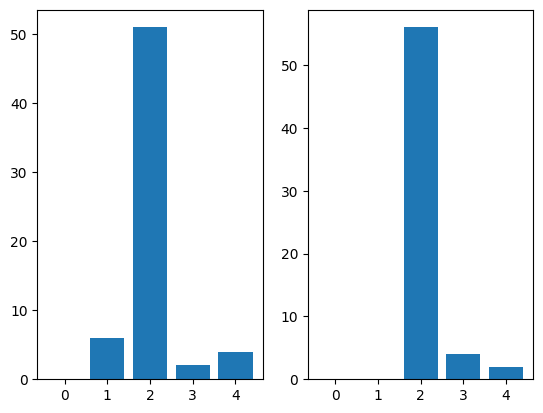

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 2)
n = 5

x = seed.layers['AD'].toarray().sum(axis = 0)
axs[0].bar([str(i) for i in range(n)], x[:n])

x = (seed.layers['DP'] - seed.layers['AD']).toarray().sum(axis = 0)
axs[1].bar([str(i) for i in range(n)], x[:n])

In [15]:
for adata in [seed, rs, scrs]:
    coef_DP = adata.var['hap0'].map({0:0, 1:1}).to_numpy()
    coef_AD = adata.var['hap0'].map({0:1, 1:-1}).to_numpy()
    adata.layers['AD_pre_phase'] = adata.layers['AD'].copy()
    adata.layers['AD'] = coef_DP * adata.layers['DP'].toarray() + coef_AD * adata.layers['AD'].toarray()

<BarContainer object of 5 artists>

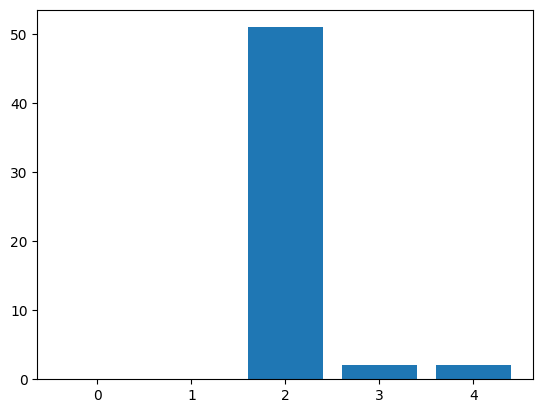

In [16]:
x = seed.layers['AD'].sum(axis = 0)
plt.bar([str(i) for i in range(n)], x[:n])

# Split by cell type

In [17]:
seed_normal = seed[seed.obs["cell_type"] == normal_cell_type, :].copy()
print(seed_normal)

rs_normal = rs[rs.obs["cell_type"] == normal_cell_type, :].copy()
print(rs_normal)

rs_tumor = rs[rs.obs["cell_type"] == tumor_cell_type, :].copy()
print(rs_tumor)

scrs_normal = scrs[scrs.obs["cell_type"] == normal_cell_type, :].copy()
print(scrs_normal)

scrs_tumor = scrs[scrs.obs["cell_type"] == tumor_cell_type, :].copy()
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH', 'AD_pre_phase'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH', 'AD_pre_phase'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH', 'AD_pre_phase'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'DP', 'OTH', 'AD_pre

# Save Data

## Check the order of cells and genes

In [18]:
assert np.all(rs_normal.var["feature"].to_numpy() == seed_normal.var["feature"].to_numpy())
assert np.all(rs_tumor.var["feature"].to_numpy() == seed_normal.var["feature"].to_numpy())
assert np.all(scrs_normal.var["feature"].to_numpy() == seed_normal.var["feature"].to_numpy())
assert np.all(scrs_tumor.var["feature"].to_numpy() == seed_normal.var["feature"].to_numpy())

In [19]:
seed_normal.write_h5ad(os.path.join(out_dir, "seed_normal.h5ad"), compression = 'gzip')
rs_normal.write_h5ad(os.path.join(out_dir, "rs_normal.h5ad"), compression = 'gzip')
rs_tumor.write_h5ad(os.path.join(out_dir, "rs_tumor.h5ad"), compression = 'gzip')
scrs_normal.write_h5ad(os.path.join(out_dir, "scrs_normal.h5ad"), compression = 'gzip')
scrs_tumor.write_h5ad(os.path.join(out_dir, "scrs_tumor.h5ad"), compression = 'gzip')